### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 3</center>
---

### Overview

The objective of this exercise is to study spatial frequencies and image sampling. The first step for this is to create periodic patterns with known frequencies. One way to describe and generate such patterns is given by the wavenumber vector $\vec{\textbf{k}} = (k_x, k_y)^\text{T}$ (see lecture notes). The following figure illustrates the method:

<img src="images/wavenumber-vector.png" width="350px" />

The distance between two maxima is the wavelength $\lambda$, which is inversely proportional to the spatial frequency (the smaller $\lambda$, the larger the spatial frequency). The vector $\vec{\textbf{k}}$ is normal to the lines of constant gray values and describes the orientation of the periodic pattern. The length of this vector is set to:

$$|\vec{\textbf{k}}| = \dfrac{1}{\lambda}$$

By this means, the wavenumber vector $\vec{\textbf{k}}$ describes both the direction *and* the wavelength of the pattern. The components $k_x$ and $k_y$ directly describe the number of wavelengths per pixel in the corresponding direction (therefore, the values should be less than 1 for a reasonable implementation). The pattern can then be described as follows:

$$f(x,y) = a + a \cos(2\pi (k_x x + k_y y) - \Phi)$$

In this equation, $a$ is the amplitude of the periodic term *and* an offset (required because the cosine has a range of $\pm 1$ and we only want positive gray values here). The shift $\Delta x$ of the first maximum line from the coordinate origin (top left) is best described as a phase angle $\Phi = 2\pi \, \Delta x / \lambda$ so that we can directly choose $\Phi \in [0, 2\pi]$.

To satisfy the sampling theorem, the sampling interval $r = \{1, 2, 3, \dots\}$ should be:

$$r \leq \dfrac{1}{2}\lambda$$

#### Plotting Images in Original Size

In the last exercise, a function has been provided to plot images in their original size. The function can be used here but images can only be displayed below each other. Instead of using complex <a href="https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.subplot.html">`subplot` ↗</a> commands to align images side by side, the results can be saved as PNG images and displayed using some HTML in a *Markdown* cell:

```
<img src="output/01.png"> <img src="output/03.png"><br />
<img src="output/02.png"> <img src="output/04.png">
```

To reload the images directly and not from the cache, just change and switch back the cell type (keyboard shortcut `m` for *Markdown* and `y` for *Code*).

---

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.1</span> Creating Periodic Patterns

Implement the following tasks:
1. Write a function to create an image with a periodic pattern using the wavenumber vector.
2. Create different periodic patterns with different parameters to test the function.
3. Create an image with 300 $\times$ 300 pixels and a periodic pattern with the following parameters:<br />
$\vec{\textbf{k}}_1 = (0.2, 0.2)^\text{T}$, $a_1 = 127.5$, $\Phi_1 = 0$
4. Create an image with 300 $\times$ 300 pixels and a periodic pattern with the following parameters:<br />
$\vec{\textbf{k}}_2 = (0.01, 0.05)^\text{T}$, $a_2 = 127.5$, $\Phi_2 = 0$

In [3]:
def create_periodic_pattern(rows, cols, a, kx, ky, phi=0):
    # create black grayscale image
    img = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    # create periodic pattern
    for iy in range(rows):
        for jx in range(cols):
            img[iy, jx] = a + a*np.cos(2*np.pi*(kx*jx+ky*iy)-phi) # x corresponds to cols (j)

    return img # final image

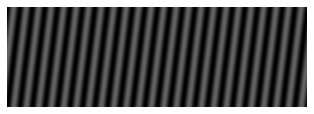

In [4]:
# test different parameters
img_test = create_periodic_pattern(100, 300, 50, 0.08, 0.01, np.pi)
plot_img_orig(img_test)

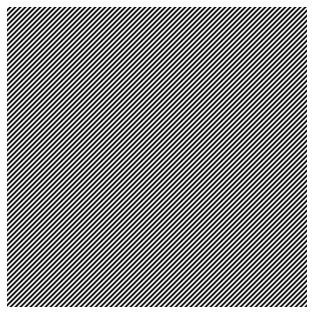

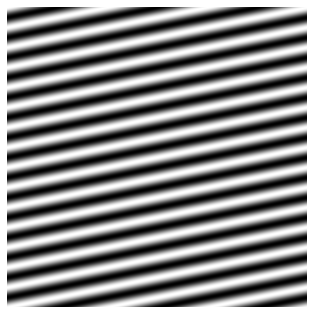

True

In [5]:
# create images with given parameters
img1 = create_periodic_pattern(300, 300, 127.5, 0.2, 0.2)
img2 = create_periodic_pattern(300, 300, 127.5, 0.01, 0.05)

# plot and save the results
plot_img_orig(img1)
plot_img_orig(img2)

cv2.imwrite('output/img1.png', img1)
cv2.imwrite('output/img2.png', img2)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.2</span> Image Sampling

Implement / solve the following tasks:
1. Write a function to sample an image with a regular sampling interval $r$.
2. Determine the range of $r$ to comply with the sampling theorem for the two images from the previous task.
3. Sample the two images from the previous task using $r=4$.
4. Plot and analyze the results. The OpenCV function <a href="https://docs.opencv.org/4.2.0/da/d54/group__imgproc__transform.html#ga47a974309e9102f5f08231edc7e7529d">`resize` ↗</a> can be used to resize the images for comparison. 
5. Test different sampling intervals and the influence of the amplitude and phase of the periodic pattern on the sampling.

In [6]:
# sample image with regular sampling interval r
def sample_image(img, r):
    rows, cols = img.shape # image size
    # create a new black image for the result
    img_s = np.zeros(shape=[int(rows/r), int(cols/r)], dtype=np.uint8)

    # sample
    rows, cols = img_s.shape # image size
    for iy in range(rows):
        for jx in range(cols):
            img_s[iy, jx] = img[r*iy, r*jx];

    return img_s # sampled image

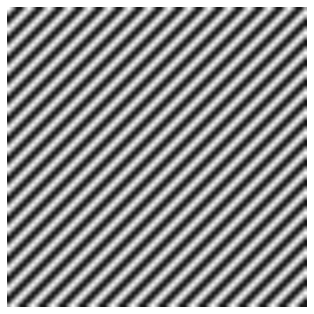

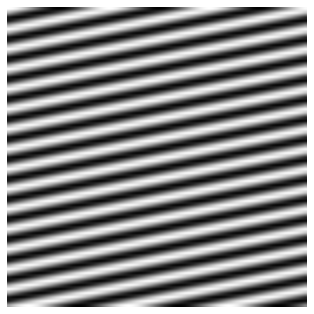

In [8]:
# sample the images
img1_s = sample_image(img1, 4)
img2_s = sample_image(img2, 4)

# plot and save the results
img1_s = cv2.resize(img1_s, (300, 300))
img2_s = cv2.resize(img2_s, (300, 300))

plot_img_orig(img1_s)
plot_img_orig(img2_s)

In [7]:
cv2.imwrite('output/img1_s.png', img1_s)
cv2.imwrite('output/img2_s.png', img2_s)

True

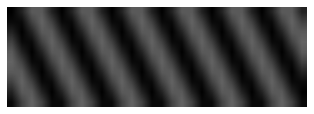

In [8]:
# test different sampling intervals and the influence of the amplitude and phase
img_test_s = sample_image(img_test, 10) # use img_test from previous task
img_test_s = cv2.resize(img_test_s, (img_test.shape[1], img_test.shape[0]))
plot_img_orig(img_test_s)

<img src="output/img1.png"> <img src="output/img1_s.png"><br />
<img src="output/img2.png"> <img src="output/img2_s.png">

The range of $r$ to comply with the sampling theorem can be determined as follows:

$$r_1 \leq \dfrac{1}{2}\lambda_1 = \dfrac{1}{2}\dfrac{1}{|\vec{\textbf{k}}_1|} = \dfrac{1}{2}\dfrac{1}{\sqrt{k_x^2 + k_y^2}} = \dfrac{1}{2}\dfrac{1}{\sqrt{0.2^2 + 0.2^2}} \approx 1.77$$

$$r_2 \leq \dfrac{1}{2}\lambda_2 = \dfrac{1}{2}\dfrac{1}{|\vec{\textbf{k}}_2|} = \dfrac{1}{2}\dfrac{1}{\sqrt{k_x^2 + k_y^2}} = \dfrac{1}{2}\dfrac{1}{\sqrt{0.01^2 + 0.05^2}} \approx 9.8$$

The first image is not sampled correctly, the waves are larger now. In other words, the sampled pattern is different to the original one. This is because the sampling theorem is not satisfied here ($4 \nleq 1.77$). For the second image, the sampling theorem is satisfied ($4 \leq 9.8$). The image is correctly sampled even if the amplitude and phase of the periodic pattern changes.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.3</span> Creating Patterns with Variable Frequency

To create periodic patterns with variable frequency, the function from above can be modified. For example, the linear term in the cosine can be replaced by a quadratric term as follows:

$$f(x,y) = a + a \cos(2\pi (k_x x^2 + k_y y^2) - \Phi)$$

As the equation of a circle with the radius $r$ in the coordinate origin is given by $x^2 + y^2 = r^2$, this should lead to circular patterns.

Implement the following tasks:
1. Write a function to create an image with a pattern using the modified function.
2. Create images with 300 $\times$ 300 pixels and $\vec{\textbf{k}}_1 = (0.01, 0.01)^\text{T}$, $\vec{\textbf{k}}_2 = (0.001, 0.001)^\text{T}$, $\vec{\textbf{k}}_3 = (0.0001, 0.0001)^\text{T}$, and $a_i=127.5$, $\Phi_i=0$ for all patterns.
3. Plot the results.

In [9]:
# create a periodic pattern using the wavenumber vector
def create_periodic_pattern2(rows, cols, a, kx, ky, phi=0):
    # create black grayscale image
    img = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    # create periodic pattern
    for iy in range(rows):
        for jx in range(cols):
            img[iy, jx] = a + a*np.cos(2*np.pi*(kx*jx*jx+ky*iy*iy)-phi) # x corresponds to cols (j)

    return img # final image

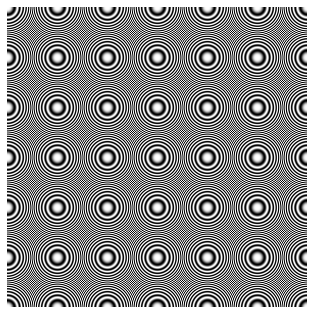

True

In [10]:
# create the patterns
img1_var = create_periodic_pattern2(300, 300, 127.5, 0.01, 0.01)
plot_img_orig(img1_var)
cv2.imwrite('output/img1_var.png', img1_var)

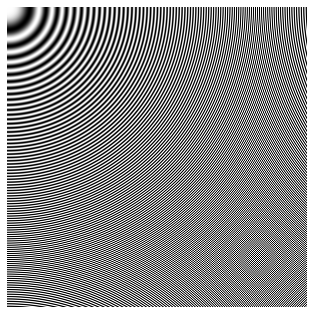

True

In [11]:
img2_var = create_periodic_pattern2(300, 300, 127.5, 0.001, 0.001)
plot_img_orig(img2_var)
cv2.imwrite('output/img2_var.png', img2_var)

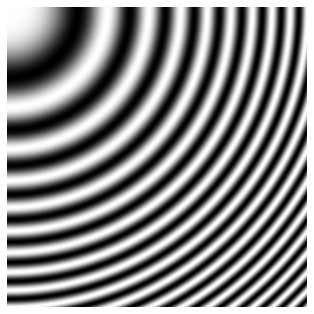

True

In [12]:
img3_var = create_periodic_pattern2(300, 300, 127.5, 0.0001, 0.0001)
plot_img_orig(img3_var)
cv2.imwrite('output/img3_var.png', img3_var)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 3.4</span> Moiré Effect

Implement the following tasks:
1. Sample the images from the previous task using different values for $r$ (e.g., 4 or 10).
2. Plot and analyze the results.

In [13]:
# sample the images
img1_var_s = sample_image(img1_var, 4)
img2_var_s = sample_image(img2_var, 4)
img3_var_s = sample_image(img3_var, 10)

# plot and save the results
img1_var_s = cv2.resize(img1_var_s, (300, 300))
img2_var_s = cv2.resize(img2_var_s, (300, 300))
img3_var_s = cv2.resize(img3_var_s, (300, 300))

#plot_img_orig(img1_var_s)
#plot_img_orig(img2_var_s)
#plot_img_orig(img3_var_s)

cv2.imwrite('output/img1_var_s.png', img1_var_s)
cv2.imwrite('output/img2_var_s.png', img2_var_s)
cv2.imwrite('output/img3_var_s.png', img3_var_s)

True

<img src="output/img1_var.png"> <img src="output/img1_var_s.png"><br />
<img src="output/img2_var.png"> <img src="output/img2_var_s.png"><br />
<img src="output/img3_var.png"> <img src="output/img3_var_s.png">

The sampling creates new patterns that were not present in the original image. In the last image, the frequency increases continuously from the top left to the bottom right. Here, the top left is still sampled correctly (due to the low frequencies), while new patterns are created at the bottom right (due to the high frequencies).